# 05 · The scoring rule, and two ways it breaks

§8.8's normalised regret is what the whole incentive design pays on. Miners earn
emissions in proportion to it (§16.1), so a defect in this formula is not an academic
matter — it is money moving to the wrong participant.

    regret = (U_oracle − U_policy) / (U_oracle − U_base + eps)

Contribution 3 (§6) identifies one defect: on an uninformative batch, where every model
performs about the same, U_oracle and U_base converge, the denominator collapses toward
`eps`, and the score becomes noise wearing a confident-looking number. Given the tie rate
from notebook 01, that should be common rather than rare.

Reproducing it turned up a second defect that neither document mentions.

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

In [2]:
mt = load("metric"); res = mt["result"]
md(f"{res['config']['n_batches']} batches of {res['config']['batch_items']} real held-out "
   f"items each, four policies of genuinely different strength (different amounts of "
   f"training data, so the true ordering is known by construction), κ calibrated at "
   f"{res['config']['kappa']:.4f}.")
pd.Series(res["true_utility"]).sort_values(ascending=False).rename("true utility over the full test split").to_frame()

400 batches of 100 real held-out items each, four policies of genuinely different strength (different amounts of training data, so the true ordering is known by construction), κ calibrated at 0.1570.

,true utility over the full test split
best (100%),0.7364
good (40%),0.7328
fair (10%),0.7212
weak (2% of train),0.6743


## Defect 1 — score noise where information is scarce

Bin the batches by how much they actually discriminate (`U_oracle − U_base`) and measure
the spread of each policy's score within each bin.

In [3]:
bins = pd.DataFrame([{ "bin": b["bin"], "mean information": b["mean_info"],
                       "batches": b["n_batches"], "raw SD": b["raw_sd_mean"],
                       "shrunk SD": b["shrunk_sd_mean"], "reduction": b["sd_reduction"]}
                     for b in res["bins"]["bins"]])
bins.set_index("bin")

,mean information,batches,raw SD,shrunk SD,reduction
bin,,,,,
0,0.1372,80,0.1628,0.0759,0.0869
1,0.1621,80,0.1449,0.0753,0.0696
2,0.1800,80,0.1293,0.0708,0.0585
3,0.1958,80,0.1186,0.0684,0.0502
4,0.2232,80,0.1113,0.0699,0.0414


In [4]:
lo, hi = bins.iloc[0], bins.iloc[-1]
md(f"""
Score SD is **{lo['raw SD']:.4f}** in the least informative bin against
**{hi['raw SD']:.4f}** in the most — **{lo['raw SD']/hi['raw SD']:.0%}** as noisy, on the
same policies, differing only in which items the batch happened to contain.
""")
finding("supported",
        f"Contribution 3's premise holds: batch score noise rises monotonically as batch "
        f"information falls ({lo['raw SD']/hi['raw SD']:.0%} more noise in the lowest bin). "
        f"A miner scored on an uninformative batch is being ranked on luck.")


Score SD is **0.1628** in the least informative bin against
**0.1113** in the most — **146%** as noisy, on the
same policies, differing only in which items the batch happened to contain.


> **SUPPORTED** — Contribution 3's premise holds: batch score noise rises monotonically as batch information falls (146% more noise in the lowest bin). A miner scored on an uninformative batch is being ranked on luck.

### Does the fix work? Ask the question that decides emissions

Reducing variance is easy — always report the same number and the variance is zero. The
question that matters for §16 is whether a single batch *ranks the policies correctly*,
because that ranking is what the payout is computed from.

In [5]:
rank = pd.DataFrame([{ "bin": b["bin"], "mean information": b["mean_info"],
                       "raw concordance": b["raw_concordance"],
                       "shrunk concordance": b["shrunk_concordance"],
                       "raw top-1": b["raw_top1_accuracy"],
                       "shrunk top-1": b["shrunk_top1_accuracy"]}
                     for b in res["ranking"]["by_bin"]])
rank.set_index("bin")

,mean information,raw concordance,shrunk concordance,raw top-1,shrunk top-1
bin,,,,,
0,0.1372,0.8333,0.9187,0.5500,0.7000
1,0.1621,0.8167,0.8688,0.4000,0.5500
2,0.1800,0.8271,0.8958,0.4750,0.6625
3,0.1958,0.8104,0.9104,0.5375,0.6875
4,0.2232,0.7396,0.8854,0.4000,0.6125


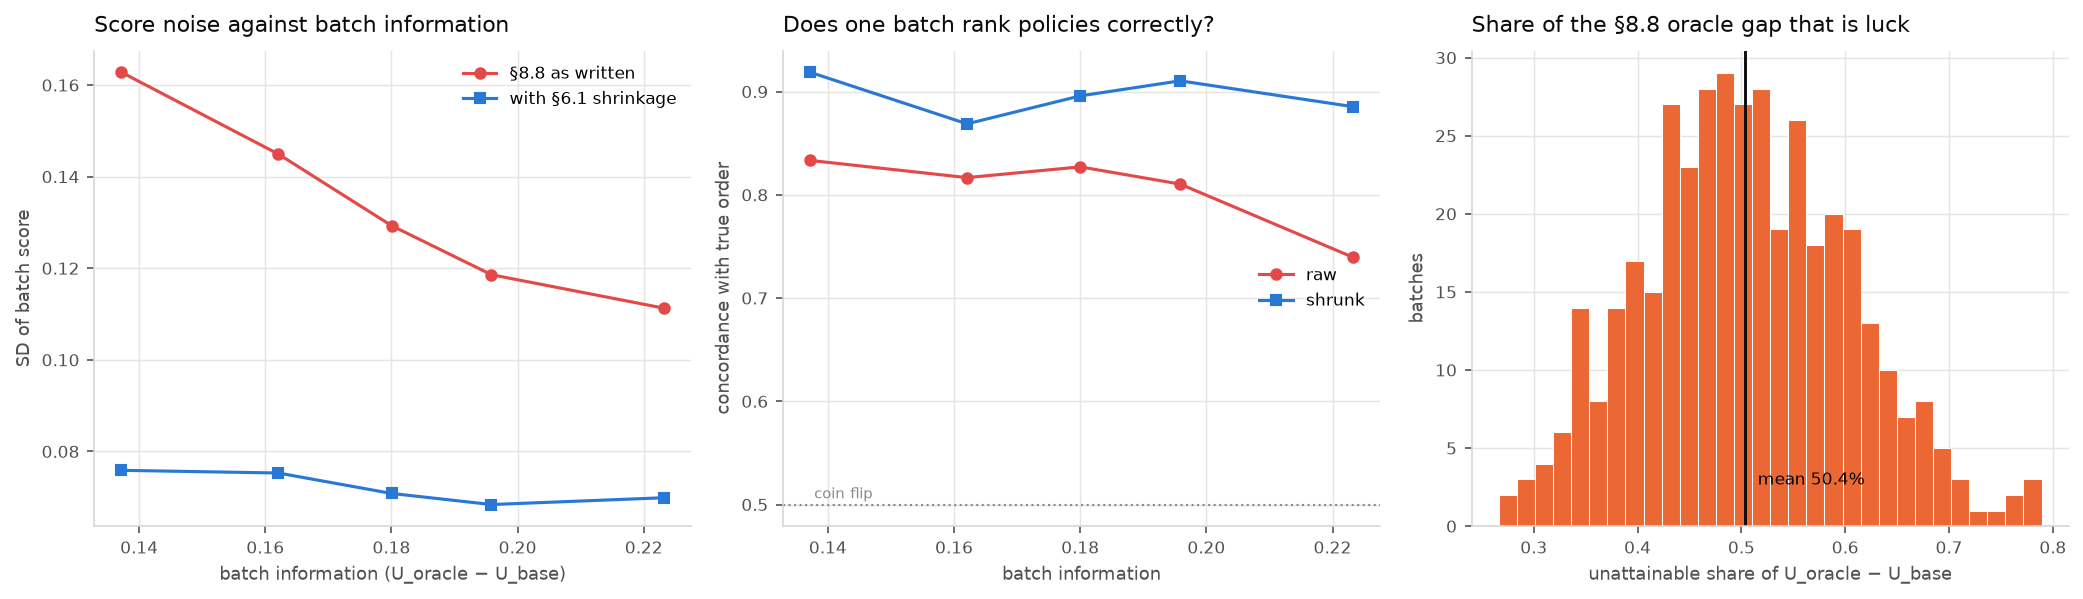

*Left: score noise against batch information, before and after shrinkage. Middle: whether one batch recovers the true policy ordering. Right: how much of the §8.8 oracle gap is luck.*

In [6]:
show("06_metric",
     "Left: score noise against batch information, before and after shrinkage. Middle: whether "
     "one batch recovers the true policy ordering. Right: how much of the §8.8 oracle gap is luck.")

In [7]:
o = res["ranking"]["overall"]
md(f"""
Concordance with the true ordering rises from **{o['raw_concordance']:.3f}** to
**{o['shrunk_concordance']:.3f}**. Top-1 accuracy — does the batch identify the single best
policy — goes from {rank['raw top-1'].mean():.1%} to {rank['shrunk top-1'].mean():.1%}.
""")
finding("supported",
        f"The §6.1 shrinkage improves what the payout actually depends on: ranking "
        f"concordance {o['raw_concordance']:.3f} → {o['shrunk_concordance']:.3f}. It does not "
        f"behave quite as §6 describes, though — it reduces noise in the high-information "
        f"bins too, because on this corpus batch information varies too little for the "
        f"weight to saturate near 1. It is a general smoother here, not a targeted fix.")


Concordance with the true ordering rises from **0.805** to
**0.896**. Top-1 accuracy — does the batch identify the single best
policy — goes from 47.2% to 64.2%.


> **SUPPORTED** — The §6.1 shrinkage improves what the payout actually depends on: ranking concordance 0.805 → 0.896. It does not behave quite as §6 describes, though — it reduces noise in the high-information bins too, because on this corpus batch information varies too little for the weight to saturate near 1. It is a general smoother here, not a targeted fix.

In [8]:
md(f"""
One number worth sitting with: even under the best configuration, a single
{res['config']['batch_items']}-item batch identifies the genuinely best of four policies
only **{rank['shrunk top-1'].max():.0%}** of the time. §16.2 smooths scores across rounds
with β ≈ 0.8, which helps — but paying emissions on single-batch scores means paying
substantially on noise, and the batch would need to be far larger for that not to be true.
""")


One number worth sitting with: even under the best configuration, a single
100-item batch identifies the genuinely best of four policies
only **70%** of the time. §16.2 smooths scores across rounds
with β ≈ 0.8, which helps — but paying emissions on single-batch scores means paying
substantially on noise, and the batch would need to be far larger for that not to be true.


In [9]:
dg = res["diagnosis"]
md(f"""
### But §6 is wrong about *why*

The fix works. Its stated diagnosis does not, and the difference changes what an operator
should do about it.

| | |
|---|---|
| §6's account | {dg['section_6_predicts']} |
| measured | **{dg['measured']}** |
| corr(information, best-minus-worst model) | **{dg['corr_info_vs_model_spread']:+.2f}** |
| corr(information, best-minus-second model) | **{dg['corr_info_vs_dominance']:+.2f}** |
""")
finding("correction", dg["reading"])


### But §6 is wrong about *why*

The fix works. Its stated diagnosis does not, and the difference changes what an operator
should do about it.

| | |
|---|---|
| §6's account | positive — similar models should mean low information |
| measured | **negative — similar models mean HIGH information** |
| corr(information, best-minus-worst model) | **-0.55** |
| corr(information, best-minus-second model) | **-0.49** |


> **CORRECTION** — batch information correlates -0.55 with the spread between the best and worst model and -0.49 with how far the best model leads the second. §6's stated cause is inverted: the degenerate batches are the ones where models differ most, because a dominant model leaves the oracle little to add. The fix keys on measured information so it still works, but filtering out 'easy' batches — the intervention §6's account suggests — would discard the informative ones.

The mechanism is the same luck that shows up again below. When every model performs about
the same, per-item noise lets the realised-outcome oracle beat *any* single model by a wide
margin — so the denominator is large and the score is stable. The denominator collapses
when one model dominates, because then the best single model is already nearly as good as
the oracle and there is almost no gap to normalise by.

This matters practically: §6's account suggests helping the metric by keeping challenge
batches hard and filtering out the easy ones. On this data that would discard the
informative batches and keep the degenerate ones.

## Defect 3 — half the oracle is luck

This one is not in either document.

§8.8's oracle is the argmax of *realised* outcomes per item. On binary grading, that
argmax banks luck: if any model in the pool happened to answer an item correctly, the
oracle takes the credit, and no policy could have predicted which one. Notebook 01 showed
95.9% of items have at least one model correct while the best individual model manages
78.1%.

The measurement: compare §8.8's per-item oracle against the best attainable per-task
assignment on the same batch, and take the difference as a share of the gap the metric
divides by.

In [10]:
lk = res["oracle_luck"]
md(f"""
| | |
|---|---|
| mean luck share of the gap | **{pct(lk['mean_luck_share_of_gap'])}** |
| median | {pct(lk['median_luck_share_of_gap'])} |
| 5th–95th percentile | {pct(lk['p5'])} – {pct(lk['p95'])} |
""")
finding("new",
        f"About {pct(lk['mean_luck_share_of_gap'])} of the oracle-to-baseline gap that §8.8 "
        f"divides by is unattainable by any policy. Every score is deflated by roughly that "
        f"factor, which is why a clairvoyant per-task oracle scores 0.078 under this metric "
        f"and why AC-1's 'regret below 0.6' cannot be met by any router. The threshold is "
        f"unreachable by construction, not by weakness.")


| | |
|---|---|
| mean luck share of the gap | **50.4%** |
| median | 50.0% |
| 5th–95th percentile | 34.4% – 67.0% |


> **NEW FINDING** — About 50.4% of the oracle-to-baseline gap that §8.8 divides by is unattainable by any policy. Every score is deflated by roughly that factor, which is why a clairvoyant per-task oracle scores 0.078 under this metric and why AC-1's 'regret below 0.6' cannot be met by any router. The threshold is unreachable by construction, not by weakness.

The fix is not complicated: define the oracle over *conditionally expected* outcomes, or
over item groups, rather than over realised ones. Both are implemented in
`rollingbench/metrics.py` and reported side by side throughout. What matters is that a
scoring rule paying real money should not have half its denominator made of noise, and
that AC-1's threshold should be restated against a reachable ceiling.

## Choosing κ honestly

κ is the one constant the shrinkage fix introduces. §12 of the implementation plan asks
for an ablation "not hiding". Here it is — and the first half of it is misleading on its
own.

In [11]:
sens = pd.DataFrame(mt["kappa_sensitivity"]["rows"])
trade = pd.DataFrame(mt["kappa_tradeoff"]["rows"])
both = sens.merge(trade[["quantile", "detection_lag_batches"]], on="quantile", how="outer")
view = both[["quantile", "kappa", "mean_weight", "concordance", "top1_accuracy",
             "mean_score_sd", "detection_lag_batches"]]
view.columns = ["info quantile", "κ", "mean weight", "concordance", "top-1",
                "score SD", "lag (batches)"]
view

,info quantile,κ,mean weight,concordance,top-1,score SD,lag (batches)
0,0.0500,0.1310,0.5741,0.8871,0.6225,0.0833,7.0000
1,0.1000,0.1406,0.5569,0.8896,0.6300,0.0810,NaN
2,0.2500,0.1570,0.5297,0.8958,0.6425,0.0773,7.0000
3,0.5000,0.1804,0.4953,0.9046,0.6500,0.0728,7.0000
4,0.7500,0.2013,0.4682,0.9113,0.6625,0.0692,NaN
5,1.0000,0.2791,0.3889,0.9283,0.7075,0.0592,9.0000
6,2.0000,0.5582,0.2422,0.9654,0.8250,0.0436,33.0000
7,5.0000,NaN,NaN,NaN,NaN,NaN,88.0000


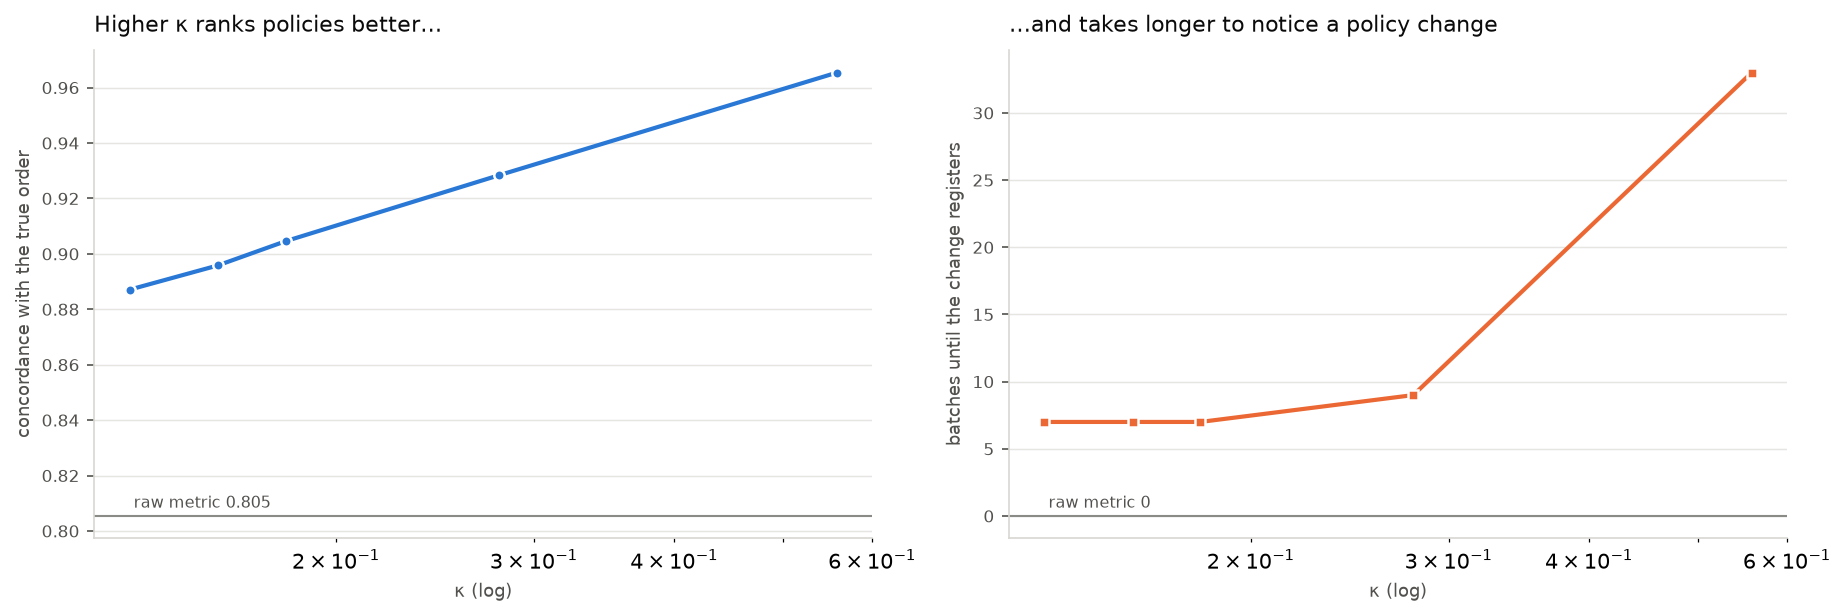

*κ trades ranking accuracy against how long the score takes to notice that a policy changed. Neither axis alone identifies an operating point.*

In [12]:
show("07_kappa", "κ trades ranking accuracy against how long the score takes to notice that a "
                 "policy changed. Neither axis alone identifies an operating point.")

In [13]:
md(f"""
Ranking accuracy improves monotonically with κ, which looks like "shrink as hard as
possible" — but that is an artefact of testing a static set of policies. As κ grows the
weight goes to zero, every score becomes the pooled running average, and pooling is
unbeatable at ranking policies that never change.

§16.2's payout is not applied to a static set: miners submit new policies, and a score
that cannot notice an improvement stops paying for one. The second axis measures that
directly — swap a policy from worst to best halfway through and count the batches until
the score catches up.

{mt['kappa_tradeoff']['reading']}
""")
finding("correction",
        f"κ at the 25th percentile of observed batch information buys "
        f"{sens.iloc[2]['concordance'] - mt['kappa_sensitivity']['raw_concordance']:+.3f} "
        f"concordance for a {trade.iloc[1]['detection_lag_batches']:.0f}-batch detection lag, "
        f"against {mt['kappa_tradeoff']['raw_detection_lag']:.0f} batches raw. Larger κ scores "
        f"better on ranking and takes up to "
        f"{trade.iloc[-1]['detection_lag_batches']:.0f} batches to notice a change. "
        f"'Calibrated once' needs to name which of the two it is calibrated for.")


Ranking accuracy improves monotonically with κ, which looks like "shrink as hard as
possible" — but that is an artefact of testing a static set of policies. As κ grows the
weight goes to zero, every score becomes the pooled running average, and pooling is
unbeatable at ranking policies that never change.

§16.2's payout is not applied to a static set: miners submit new policies, and a score
that cannot notice an improvement stops paying for one. The second axis measures that
directly — swap a policy from worst to best halfway through and count the batches until
the score catches up.

κ trades ranking accuracy (kappa_sensitivity) against detection lag (here); the operating point is the largest κ whose lag is still acceptable for the payout cadence, not the κ that maximises either one


> **CORRECTION** — κ at the 25th percentile of observed batch information buys +0.090 concordance for a 7-batch detection lag, against 0 batches raw. Larger κ scores better on ranking and takes up to 88 batches to notice a change. 'Calibrated once' needs to name which of the two it is calibrated for.